<a href="https://colab.research.google.com/github/zahira456/Zahira-Nur-Asyifa_2411532015_ML2526/blob/main/Praktikum1/SIngleLinierRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/advertising.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print(df.head())

Shape: (200, 4)
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [ ]:
print("\nDescriptive stats:")
print(df.describe().T)



Descriptive stats:
           count      mean        std  min     25%     50%      75%    max
TV         200.0  147.0425  85.854236  0.7  74.375  149.75  218.825  296.4
Radio      200.0   23.2640  14.846809  0.0   9.975   22.90   36.525   49.6
Newspaper  200.0   30.5540  21.778621  0.3  12.750   25.75   45.100  114.0
Sales      200.0   15.1305   5.283892  1.6  11.000   16.00   19.050   27.0


<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

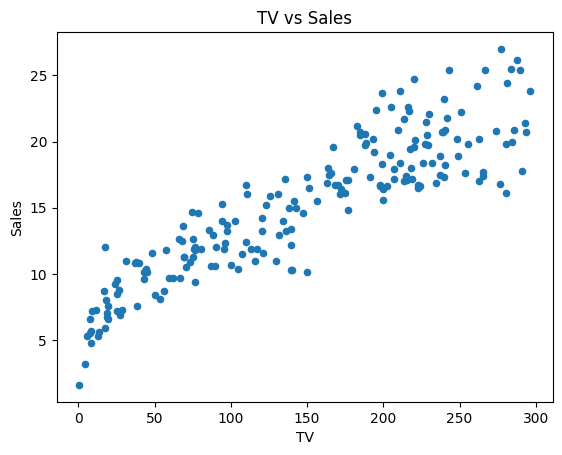

In [ ]:
plt.figure()
df.plot(kind='scatter', x='TV', y='Sales')
plt.title('TV vs Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show


In [ ]:
X = df[["TV"]]
y = df[["Sales"]]

reg_model = LinearRegression().fit(X, y)

print("\n=== Simple Linear Regression (Sales ~ TV) ===")
print("Intercpet (b0):", reg_model.intercept_[0])
print("COefficient TV (b1):", reg_model.coef_[0] [0])


=== Simple Linear Regression (Sales ~ TV) ===
Intercpet (b0): 6.974821488229891
COefficient TV (b1): 0.055464770469558874


In [ ]:
tv_150 = reg_model.intercept_[0] + reg_model.coef_[0] [0] * 150
tv_500 = reg_model.intercept_[0] + reg_model.coef_[0][0] * 500
print("Prediksi Sales jika TV = 150:", tv_150)
print("Prediksi Sales jika TV = 500:", tv_500)

Prediksi Sales jika TV = 150: 15.294537058663721
Prediksi Sales jika TV = 500: 34.70720672300933


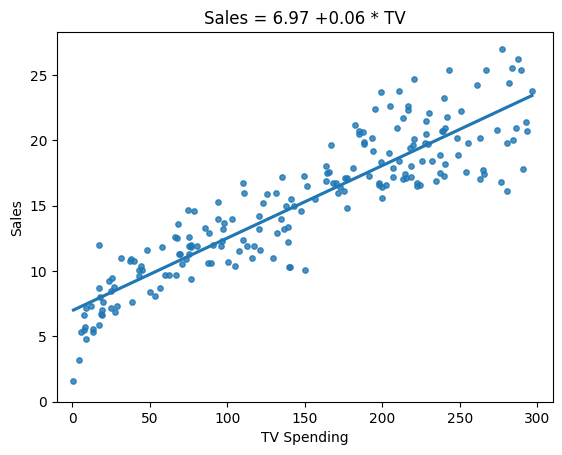

In [ ]:
plt.figure()
sns.regplot(x=X, y=y, scatter_kws={'s': 15}, ci=False)
plt.title(f"Sales = {reg_model.intercept_[0]:.2f} +{reg_model.coef_[0][0]:.2f} * TV")
plt.xlabel("TV Spending")
plt.ylabel("Sales")
plt.xlim(-10, 310)
plt.ylim(bottom=0)
plt.show()

In [ ]:
X_multi = df.drop("Sales", axis=1)
y_multi = df[["Sales"]]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.3, random_state=1)
print("Shape data latih:", X_train.shape, y_train.shape)
print("Shape data uji:", X_test.shape, y_test.shape)

Shape data latih: (140, 3) (140, 1)
Shape data uji: (60, 3) (60, 1)


In [ ]:
reg_model_multi = LinearRegression().fit(X_train, y_train)

print("\n===Multiple Linear Regression (Train/Test Split) ===")
print("Intercept:", reg_model_multi.coef_)
print("Coefficient [Tv, radio, newspaper]:", reg_model_multi.coef_)


===Multiple Linear Regression (Train/Test Split) ===
Intercept: [[ 0.05502392  0.10251003 -0.00150711]]
Coefficient [Tv, radio, newspaper]: [[ 0.05502392  0.10251003 -0.00150711]]


In [ ]:
new_data = pd.DataFrame([[30, 10, 40]], columns=["TV", "Radio", "Newspaper"])
pred_new = reg_model_multi.predict(new_data)[0][0]
print("Prediksi Sales untuk (TV=30 , Radio=10, Newspaper=40):", pred_new)

Prediksi Sales untuk (TV=30 , Radio=10, Newspaper=40): 7.276973308377115


In [ ]:
y_pred_train = reg_model_multi.predict(X_train)
y_pred_test = reg_model_multi.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

r2_train = reg_model_multi.score(X_train, y_train)
r2_test = reg_model_multi.score(X_test, y_test)

print("\nRMSE Train:", rmse_train)
print("RMSE Test :", rmse_test)
print("R^2 Train:", r2_train)
print("R^2 Test:", r2_test)


RMSE Train: 1.6929025956077548
RMSE Test : 1.5396947656031237
R^2 Train: 0.899374584012456
R^2 Test: 0.9071151423684273
